# UNSUPERVISED LEARNING

without any kind of previous data training
machine's job is to organize unsorted data into specific classes

# K-Means clustering algorithm

In [2]:
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [3]:
df = sns.load_dataset('iris')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


clusters are: 
 0      1
1      1
2      1
3      1
4      2
      ..
145    0
146    0
147    0
148    0
149    0
Name: cluster, Length: 150, dtype: int32
clusters centers: (scaled):
[[ 0.50728948 -0.42663134  0.65249366  0.62744675 -0.64893273]
 [-1.19647332  0.40288948 -1.3134795  -1.26511434  0.82591438]
 [-0.62805346  1.81030574 -1.28694144 -1.23317418  2.3007615 ]]
Silhouette score:  0.5782430808363102


Text(0.5, 1.0, 'K-Means clusters on iris (Scaled data)')

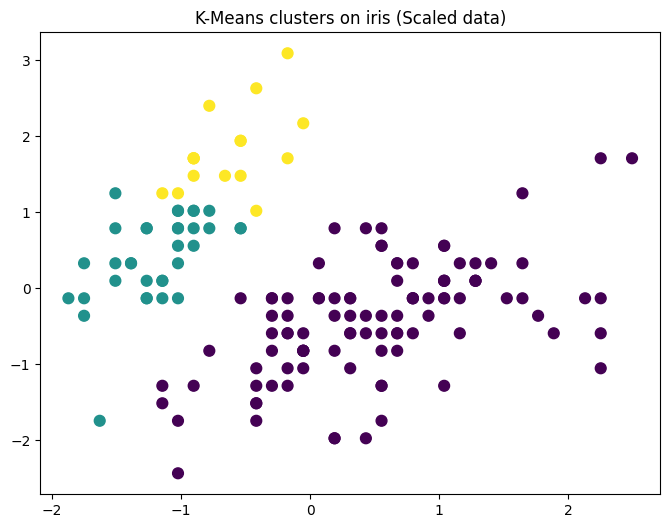

In [18]:
X = df.drop('species',axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# applying k-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
# adding cluster lables to dataframe
df['cluster'] = kmeans.labels_

print('clusters are: \n',df['cluster'])
print('clusters centers: (scaled):')
print(kmeans.cluster_centers_)

#evaluating the clustering
sil_score = silhouette_score(X_scaled, kmeans.labels_)

print("Silhouette score: ",sil_score)

# plot clusters
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=kmeans.labels_,s=60)
plt.title('K-Means clusters on iris (Scaled data)')


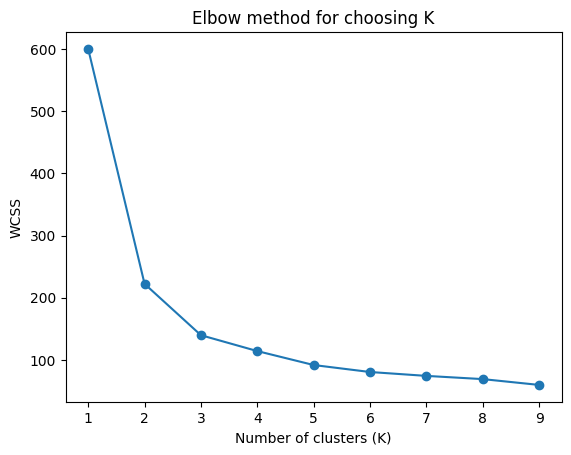

In [11]:
wcss = []
for k in range(1,10):
      km = KMeans(n_clusters=k)
      km.fit(X_scaled)
      wcss.append(km.inertia_)

plt.plot(range(1,10),wcss,marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel('WCSS')
plt.title("Elbow method for choosing K")
plt.show()